In [16]:
import sys

In [1]:
import os
import langchain
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
from langchain import hub
from langchain_community.document_loaders import DirectoryLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_community.docstore.in_memory import InMemoryDocstore
langchain.__version__


'0.3.27'

In [2]:
with open("data/secrets/key.secret") as f:
    os.environ["OPENAI_API_KEY"] = f.read()

In [3]:
loader = DirectoryLoader("data/wiki/")
docs = loader.load()
len(docs)

libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider installing libmagic for better results.
libmagic is unavailable but assists in filetype detection. Please consider insta

29

In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
len(all_splits)

369

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)
db = vector_store.add_documents(documents=all_splits)
db

['3fdb8f38-e25d-4149-aaf8-d8ef6476b6c9',
 '5bcd08b9-0e11-4154-a5fb-e9d344ce47a3',
 '0d637d95-bde5-4e52-bfe9-74d57539d4a1',
 'da64b594-241a-424d-b043-ded94dd97506',
 '21462639-e0a8-499d-82d4-9cae240daaea',
 '5f2ad9d4-3f8e-452d-8006-98be94d930fe',
 '986d7842-3541-4b3b-97cb-c4263503c04d',
 'b987c7ec-b58b-43d5-9ed4-15cbf0c89ed7',
 'c47f8ec0-db6d-48d8-9811-b323f23b87a4',
 '00fcc30a-d209-4346-b2d3-4faa2af59692',
 '36f535b0-3d66-4e41-a854-36be45ef5cce',
 '0e3e4f2c-5e0d-486d-b477-7dae3b2445b8',
 'c0f62913-a11c-4dc5-ac25-0f247d47254a',
 '4700ed33-32a6-49c5-80de-ea5525ea0eb1',
 'c7e7b12f-d00b-4496-8acf-9e7da57a67a5',
 '645a99ee-1561-4c44-bd8c-62c1a8af130d',
 'f9f9ce92-fb55-4b4c-b8cc-92d0e83dd8e8',
 '44e30130-ce6c-4874-9847-34088fe5efd8',
 '1450daec-e257-4462-a5ce-a2dc80c002c7',
 'a16b40cb-708b-49d2-8706-28df5d297019',
 'c98d1ad1-9099-4146-98ee-b60954289650',
 'f39b1df7-8ca1-4d16-a9c3-aa6ebe561bf7',
 'd258c0c4-df78-4d0f-87ec-0b1a4502ee97',
 '7b88f674-1271-45f6-88c9-8d7440c53747',
 'a040ea92-bbd7-

In [8]:
template="""
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use {nb} sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:
"""
prompt = ChatPromptTemplate.from_messages(
    [("user", template)]
)
prompt

ChatPromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, template="\nYou are an assistant for question-answering tasks.\nUse the following pieces of retrieved context to answer the question.\nIf you don't know the answer, just say that you don't know.\nUse {nb} sentences maximum and keep the answer concise.\nQuestion: {question}\nContext: {context}\nAnswer:\n"), additional_kwargs={})])

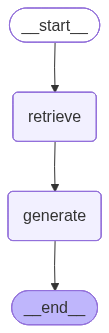

In [9]:
llm = init_chat_model("gpt-4o-mini", model_provider="openai")

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content, "nb":3})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [10]:
response = graph.invoke({"question": "Qu'est ce que le RAG?"})
response

{'question': "Qu'est ce que le RAG?",
 'context': [Document(id='20866a53-4bd5-4f68-8d4e-f3af13f4413c', metadata={'source': 'data\\wiki\\Retrieval-augmented_generation.txt'}, page_content='RAG improves large language models (LLMs) by incorporating information retrieval before generating responses. Unlike traditional LLMs that rely on static training data, RAG pulls relevant text from databases, uploaded documents, or web sources. According to Ars Technica, "RAG is a way of improving LLM performance, in essence by blending the LLM process with a web search or other document look-up process to help LLMs stick to the facts." This method helps reduce AI hallucinations, which have caused chatbots to describe policies that don\'t exist, or recommend nonexistent legal cases to lawyers that are looking for citations to support their arguments.\n\nRAG also reduces the need to retrain LLMs with new data, saving on computational and financial costs. Beyond efficiency gains, RAG also allows LLMs to

In [35]:
response["answer"]

"Le RAG, ou Retrieval-Augmented Generation, est une technique qui améliore les modèles de langage en incorporant un mécanisme de recherche d'informations, permettant aux modèles d'accéder à des données supplémentaires au-delà de leur formation initiale. Cela réduit la nécessité de former fréquemment les modèles tout en leur permettant d'utiliser des informations mises à jour pour générer des réponses plus précises. Toutefois, le RAG ne résout pas entièrement le problème des hallucinations, car les modèles peuvent encore générer des réponses incorrectes basées sur les sources consultées."